In [1]:
from prometheus_pandas import query
import datetime as dt
from zoneinfo import ZoneInfo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

local_address = "nova-11.lyon.grid5000.fr"
local_port = "30090"
p = query.Prometheus(f"http://admin:prom-operator@{local_address}:{local_port}")    

local_tz = ZoneInfo("Europe/Paris")

def execute_query_range(experiment, metric_query, step, output_filename, plot=False):
    tput_series = []

    print("\nBeginning request execution")
    for label, config in experiment.items():    
        df_metric = p.query_range(
            query=metric_query,
            start=config['start'].isoformat(),
            end=config['end'].isoformat(),
            step=step
        )

        tput_series.append(df_metric)

    if tput_series:
        combined_df = pd.concat(tput_series, axis=1)
        combined_df.to_csv(output_filename, index_label='Time')
        print(f"\nFile saved : '{output_filename}'")
        if plot:
            plt.figure(figsize=(12, 8))
            ax = combined_df.boxplot(grid=True, patch_artist=True)
            plt.title(metric_query)
            plt.show()
    else:
        print("\nRequest Error")

In [42]:
exp_q3 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 30, 15, 18, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 30, 15, 28, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 30, 15, 31, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 30, 15, 41, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 30, 15, 44, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 30, 15, 54, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 30, 15, 57, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 30, 16, 7, 0, tzinfo=local_tz)
    }
}
exp_q5 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 30, 16, 10, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 30, 16, 20, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 30, 16, 22, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 30, 16, 32, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 30, 16, 35, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 30, 16, 45, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 30, 16, 48, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 30, 16, 58, 0, tzinfo=local_tz)
    }
}
exp_q8 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 31, 9, 50, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 31, 9, 59, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 31, 10, 3, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 31, 10, 13, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 31, 10, 17, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 31, 10, 27, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 31, 10, 31, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 31, 10, 41, 0, tzinfo=local_tz)
    }
}

exp_q11 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 31, 10, 44, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 31, 10, 54, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 31, 10, 58, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 31, 11, 8, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 31, 11, 11, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 31, 11, 21, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 31, 11, 24, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 31, 11, 34, 0, tzinfo=local_tz)
    }
}

In [43]:
metric_query = 'flink_taskmanager_Status_JVM_CPU_Load{component="taskmanager"}'
step = "5s"
output_filename = 'exp2b_q11_cpu_load.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = 'flink_jobmanager_job_lastCheckpointDuration{component="jobmanager"}'
step = "30s"
output_filename = 'exp2b_q11_cp_time.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_receive_bytes_total{namespace="minio-tenant", pod=~"myminio-.*"}[5m]))'
step = "5s"
output_filename = 'exp2b_q11_minio_bytes.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = 'sum(flink_taskmanager_job_task_operator_column_family_rocksdb_total_sst_files_size{component="taskmanager"})'
step = "5s"
output_filename = 'exp2b_q11_sst_size.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_transmit_bytes_total{node="nova-9.lyon.grid5000.fr"}[5m]))'
step = "5s"
output_filename = 'exp2b_q11_bytes_send.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = 'sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_hit{component="taskmanager"}[5m]))/(sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_miss{component="taskmanager"}[5m]))+sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_hit{component="taskmanager"}[5m])))'
step = "5s"
output_filename = 'exp2b_q11_cache_rate.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)


Beginning request execution

File saved : 'exp2b_q11_cpu_load.csv'

Beginning request execution

File saved : 'exp2b_q11_cp_time.csv'

Beginning request execution

File saved : 'exp2b_q11_minio_bytes.csv'

Beginning request execution

File saved : 'exp2b_q11_sst_size.csv'

Beginning request execution

File saved : 'exp2b_q11_bytes_send.csv'

Beginning request execution

File saved : 'exp2b_q11_cache_rate.csv'


### BoxPlot

<Figure size 1000x700 with 0 Axes>

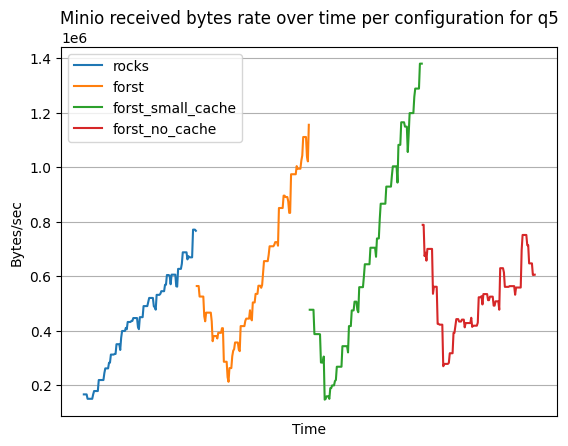

In [2]:
file_path = 'exp2b_q5_minio_bytes.csv'

try:
    df = pd.read_csv(file_path, index_col=0)
    
    df.columns = ['rocks', 'forst', 'forst_small_cache', 'forst_no_cache']
    #df = df.iloc[:, :-1] 

    plt.figure(figsize=(10, 7))
    df.plot(grid=True)
    #df.boxplot(grid=True, patch_artist=True)
    plt.title('Minio received bytes rate over time per configuration for q5')
    plt.ylabel('Bytes/sec')
    plt.xlabel('Time')
    plt.xticks([])
    #plt.yticks(np.arange(0, 1.2, 0.2))
    plt.savefig('exp2b_q5_minio_bytes_plot.png')
    
    plt.show()
    
except FileNotFoundError:
    print(f"Le fichier '{file_path}' est introuvable.")
except Exception as e:
    print(f"Une erreur est survenue : {e}")